In [1]:
import os
from pathlib import Path

import ee
import geemap
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import seaborn as sns
from psmpy import PsmPy
from scipy.stats import ks_2samp, ttest_ind

from belo_horizonte.bounds import load_bounds
from belo_horizonte.canopy import get_canopy_area
from belo_horizonte.sample import generate_full_samples
from belo_horizonte.temperature import get_lst

c:\Users\lain\Documents\belo_horizonte\.venv\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
YEAR = 2020

In [3]:
PROJECT_NAME = os.environ["PROJECT_NAME"]
ee.Initialize(project=PROJECT_NAME)

In [4]:
GREEN = "#2E8B57"
BROWN = "#A0522D"

In [5]:
data_path = Path("./data")

figure_path = Path("./figures")
figure_path.mkdir(parents=True, exist_ok=True)

results_path = Path("./results")
results_path.mkdir(parents=True, exist_ok=True)

# Bounds

In [6]:
bounds_ee = load_bounds(data_path)

# Canopy

In [7]:
img_canopy = (
    ee.ImageCollection("projects/sat-io/open-datasets/facebook/meta-canopy-height")
    .filterBounds(bounds_ee)
    .first()
)

canopy_mask = (
    ee.image.Image("projects/ee-ursa-test/assets/belo_horizonte/height_3")
    .divide(900)
    .clamp(0, 1)
    .gte(0.3)
    .rename(["type"])
    .selfMask()
)

# Temperature

In [13]:
lst.reduceRegion(ee.Reducer.percentile([5, 95]), bounds_ee, scale=30).getInfo()

{'b2020_p5': 33.313701273359264, 'b2020_p95': 43.18640938258682}

In [22]:
lst = get_lst(
    col_name="LANDSAT/LC08/C02/T1_L2",
    year=YEAR,
    temp_band="ST_B10",
    qa_band="QA_PIXEL",
    bounds=bounds_ee,
)

m = geemap.Map(center=[-19.9207, -43.9378], zoom=12)
m.addLayer(lst.clip(bounds_ee), {"bands": ["b2020"], "palette": ["#fef0d9", "#fdcc8a", "#fc8d59", "#e34a33", "#b30000"], "min": 33, "max": 43})
m.addLayer(canopy_mask.clip(bounds_ee), {"bands": ["type"], "palette": "Greens"})
m

Map(center=[-19.9207, -43.9378], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

# Regions

In [194]:
df_regions = gpd.read_file(
    data_path / "PL_limite_areas_BH_VERDE_AZUL.zip",
).filter(["ID_DESTINA", "geometry"])

df_regions_heights = get_canopy_area(
    img_canopy,
    geemap.geopandas_to_ee(df_regions.to_crs("EPSG:4326")),
    index_col="ID_DESTINA",
)

In [195]:
df_full_regions = gpd.read_file(
    data_path / "PL_limite_area_verde_publica.zip",
).assign(fid=lambda df: df["fid"].astype(int))

df_full_regions_heights = get_canopy_area(
    img_canopy,
    geemap.geopandas_to_ee(df_full_regions.to_crs("EPSG:4326")),
    index_col="fid",
)

# Histogram

In [196]:
h1 = (
    df_regions_heights.drop(columns=[0, 1, 2])
    .sum(axis=1)
    .divide(df_regions_heights.sum(axis=1))
)
h2 = (
    df_full_regions_heights.drop(columns=[0, 1, 2])
    .sum(axis=1)
    .divide(df_full_regions_heights.sum(axis=1))
)
heights = pd.concat(
    [
        h1.rename("area_frac").to_frame().assign(Tipo="Degradada"),
        h2.rename("area_frac").to_frame().assign(Tipo="Área verde"),
    ],
    ignore_index=True,
)

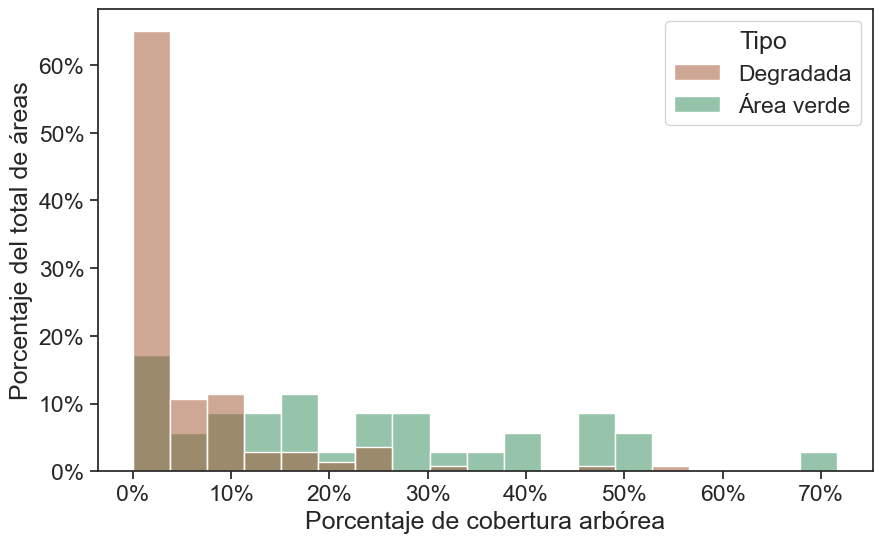

In [197]:
sns.set_theme(style="ticks", font_scale=1.5)

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    heights,
    x="area_frac",
    hue="Tipo",
    common_norm=False,
    stat="percent",
    fill=True,
    multiple="layer",
    ax=ax,
    palette=[BROWN, GREEN],
)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(100))
ax.set_xlabel("Porcentaje de cobertura arbórea")
ax.set_ylabel("Porcentaje del total de áreas")
fig.savefig(
    figure_path / "canopy_coverage_histogram.jpg",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

# Heat

In [198]:
col_regions = geemap.geopandas_to_ee(df_regions.to_crs("EPSG:4326"))
temp_regions = ee.data.computeFeatures(
    {
        "expression": lst.reduceRegions(
            collection=col_regions,
            reducer=ee.Reducer.mean(),
            scale=30,
        ),
        "fileFormat": "GEOPANDAS_GEODATAFRAME",
    },
)

In [199]:
col_regions_full = geemap.geopandas_to_ee(df_full_regions.to_crs("EPSG:4326"))
temp_regions_full = ee.data.computeFeatures(
    {
        "expression": lst.reduceRegions(
            collection=col_regions_full,
            reducer=ee.Reducer.mean(),
            scale=30,
        ),
        "fileFormat": "GEOPANDAS_GEODATAFRAME",
    },
)

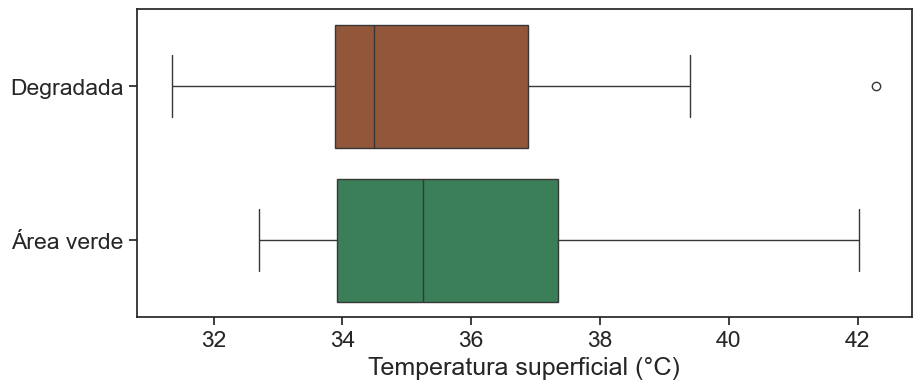

In [200]:
sns.set_theme(style="ticks", font_scale=1.5)

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(
    pd.concat(
        [
            temp_regions[["mean"]].assign(Tipo="Degradada"),
            temp_regions_full[["mean"]].assign(Tipo="Área verde"),
        ],
        ignore_index=True,
    ),
    x="mean",
    y="Tipo",
    ax=ax,
    hue="Tipo",
    palette=[BROWN, GREEN],
)
# centigrados
ax.set_xlabel("Temperatura superficial (°C)")
ax.set_ylabel("")
fig.savefig(
    figure_path / "lst_boxplot.jpg",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

# Points

In [201]:
# df_samples_control = generate_full_samples(df_regions.set_index("ID_DESTINA").assign(geometry=lambda df: df["geometry"].centroid)["geometry"], data_path=data_path, bounds=bounds_ee)
points_control = (
    df_regions.sample_points(2, seed=42)
    .explode()
    .reset_index(drop=True)
    .rename("geometry")
)
df_samples_control = generate_full_samples(
    points_control,
    data_path=data_path,
    bounds=bounds_ee,
)

In [202]:
points_treatment = (
    (
        ee.data.computeFeatures(
            {
                "expression": ee.image.Image.constant(1)
                .addBands(canopy_mask)
                .stratifiedSample(
                    numPoints=2000,
                    classBand="type",
                    region=bounds_ee,
                    scale=30,
                    geometries=True,
                    seed=42,
                ),
                "fileFormat": "GEOPANDAS_GEODATAFRAME",
            },
        )
        .drop(columns=["constant", "type"])
        .reset_index(names="index")
    )
    .set_crs("EPSG:4326")
    .to_crs(df_regions.crs)["geometry"]
)

df_samples_treatment = generate_full_samples(
    points_treatment,
    data_path=data_path,
    bounds=bounds_ee,
)

In [213]:
df_samples = pd.concat(
    [df_samples_control.assign(type=0), df_samples_treatment.assign(type=1)],
    ignore_index=True,
)

temp = df_samples.filter(like="landuse").isna().all(axis=1)
unwanted_idx = temp[temp].index

df_samples = df_samples.drop(index=unwanted_idx).reset_index(drop=True)

col_samples = geemap.geopandas_to_ee(
    df_samples[["geometry"]].reset_index(names="index").to_crs("EPSG:4326"),
)

temperature = ee.data.computeFeatures(
    {
        "expression": lst.sampleRegions(
            collection=col_samples,
            scale=30,
            geometries=False,
        ),
        "fileFormat": "GEOPANDAS_GEODATAFRAME",
    },
).set_index("index")[f"b{YEAR}"]

df_samples = df_samples.assign(temp=temperature)

df_samples.loc[lambda df: (df["type"] == 0) & (df["temp"].isna()), "temp"] = (
    df_samples.loc[lambda df: df["type"] == 0, "temp"].mean()
)
df_samples.loc[lambda df: (df["type"] == 1) & (df["temp"].isna()), "temp"] = (
    df_samples.loc[lambda df: df["type"] == 1, "temp"].mean()
)

In [215]:
df_samples.to_file("./df_samples.gpkg")

# Matching

In [216]:
not_matched = df_samples.reset_index(names="index").drop(columns=["geometry"])

psm = PsmPy(not_matched, treatment="type", indx="index", seed=42, exclude=["temp"])
psm.logistic_ps(balance=True)

psm.kdtree_matched(
    matcher="propensity_logit",
    replacement=False,
    caliper=0.05,
    drop_unmatched=True,
)

# psm.kdtree_matched_12n(matcher="propensity_logit", how_many=2)

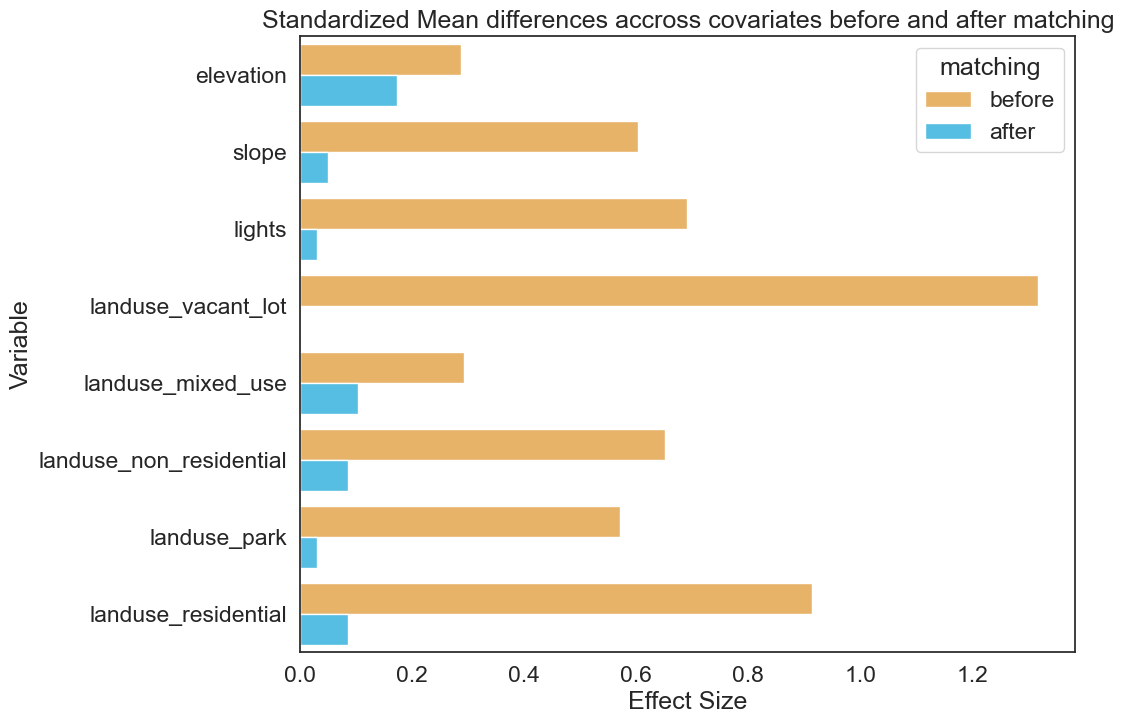

In [217]:
psm.effect_size_plot()

<Axes: xlabel='propensity_logit', ylabel='Density'>

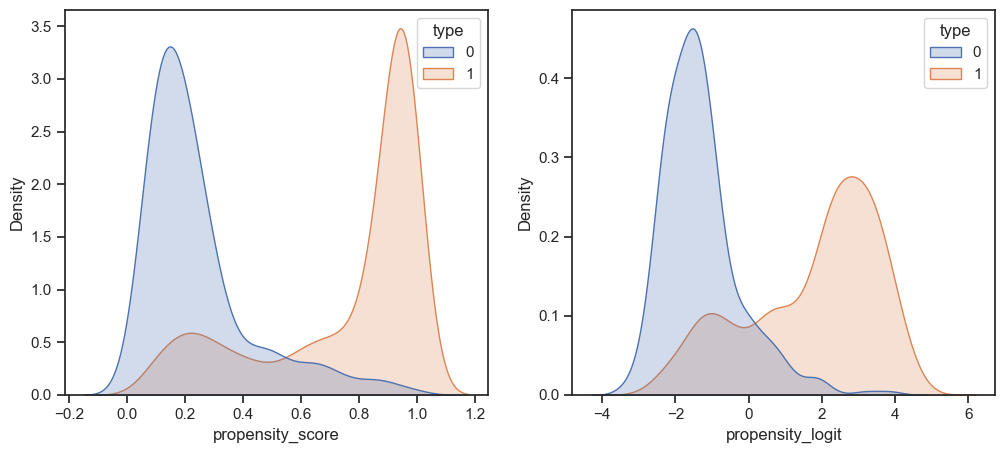

In [219]:
sns.set_theme(style="ticks")

fig, (axl, axr) = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(
    psm.predicted_data,
    hue="type",
    x="propensity_score",
    ax=axl,
    common_norm=False,
    shade=True,
)
sns.kdeplot(
    psm.predicted_data,
    hue="type",
    x="propensity_logit",
    ax=axr,
    common_norm=False,
    shade=True,
)

In [220]:
df_pairs = psm.matched_ids.reset_index(names="pair_id")

matched_treatment = df_samples.loc[df_pairs["matched_ID"]].assign(
    pair_id=df_pairs.set_index("matched_ID")["pair_id"]
)
matched_control = df_samples.loc[df_pairs["index"]].assign(
    pair_id=df_pairs.set_index("index")["pair_id"]
)
matched = pd.concat([matched_treatment, matched_control]).dropna()

matched.to_file("./df_matched.gpkg")

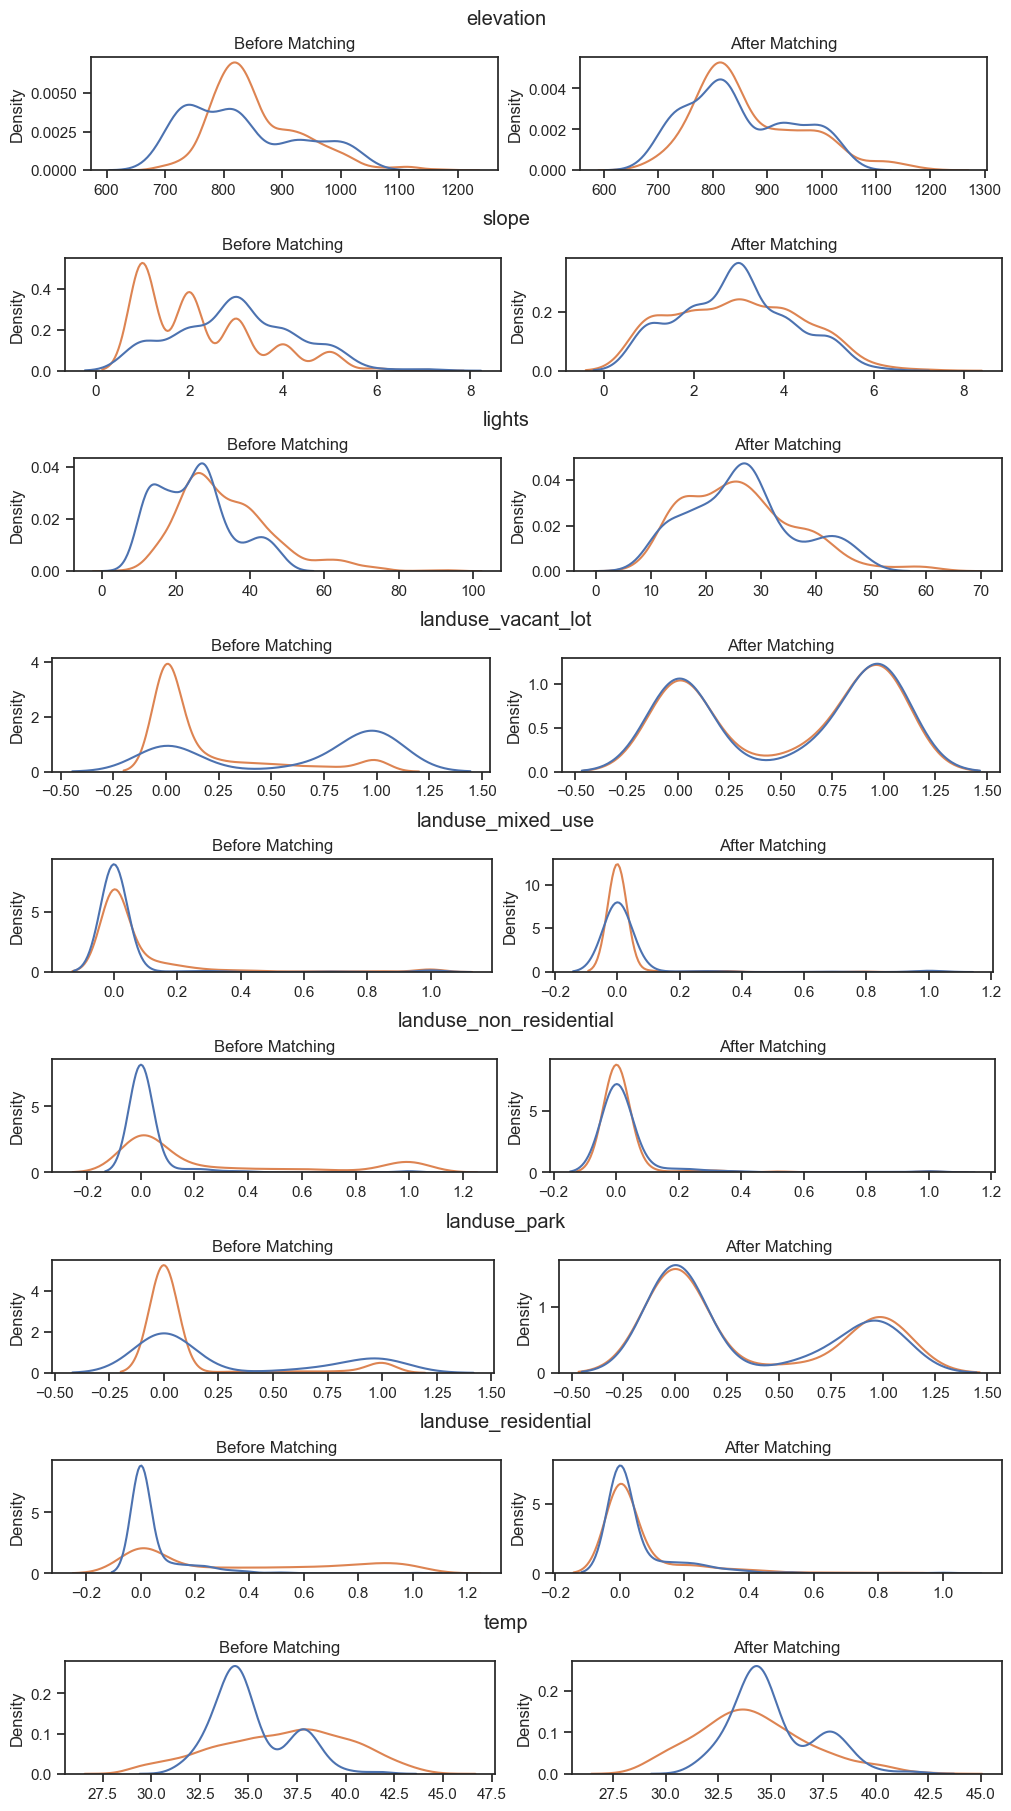

In [221]:
sns.set_theme(style="ticks")

wanted_cols = df_samples.columns.drop(
    ["type", "geometry", "start_temp", "end_temp"],
    errors="ignore",
)

fig = plt.figure(figsize=(10, 2 * len(wanted_cols)), constrained_layout=True)
subfigs = fig.subfigures(len(wanted_cols), 1)

for var, subfig in zip(wanted_cols, subfigs, strict=False):
    axl, axr = subfig.subplots(1, 2)
    sns.kdeplot(
        data=not_matched,
        x=var,
        hue="type",
        ax=axl,
        common_norm=False,
        legend=False,
    )
    sns.kdeplot(
        data=matched,
        x=var,
        hue="type",
        ax=axr,
        common_norm=False,
        legend=False,
    )

    # sns.histplot(data=not_matched, x=var, hue="type", ax=axl, common_norm=False, stat="density", legend=False)
    # sns.histplot(data=matched, x=var, hue="type", ax=axr, common_norm=False, stat="density", legend=False)

    axl.set_title("Before Matching")
    axr.set_title("After Matching")
    axl.set_xlabel("")
    axr.set_xlabel("")
    subfig.suptitle(var)

fig.savefig(
    figure_path / "psm_matching.jpg",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

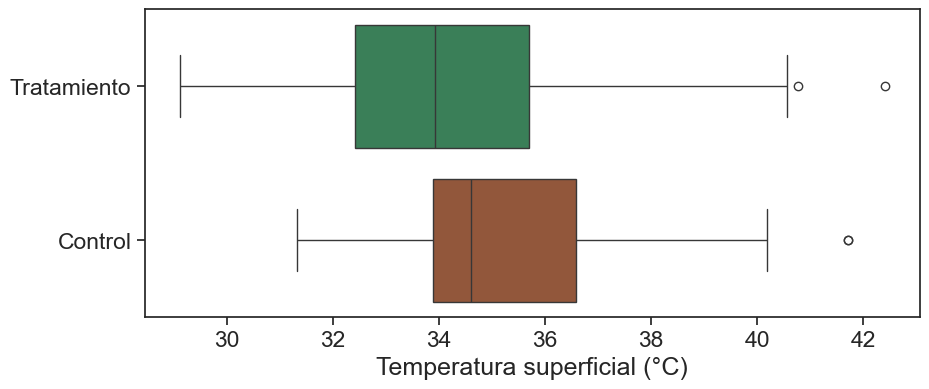

In [222]:
sns.set_theme(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(
    matched.assign(type=lambda df: df["type"].map({0: "Control", 1: "Tratamiento"})),
    x="temp",
    y="type",
    hue="type",
    palette=[GREEN, BROWN],
    ax=ax,
)
ax.set_xlabel("Temperatura superficial (°C)")
ax.set_ylabel("")
fig.savefig(
    figure_path / "lst_matched_boxplot.jpg",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

In [224]:
matched_control["temp"].mean() - matched_treatment["temp"].mean()

np.float64(1.011550438429495)

<Axes: xlabel='temp', ylabel='Density'>

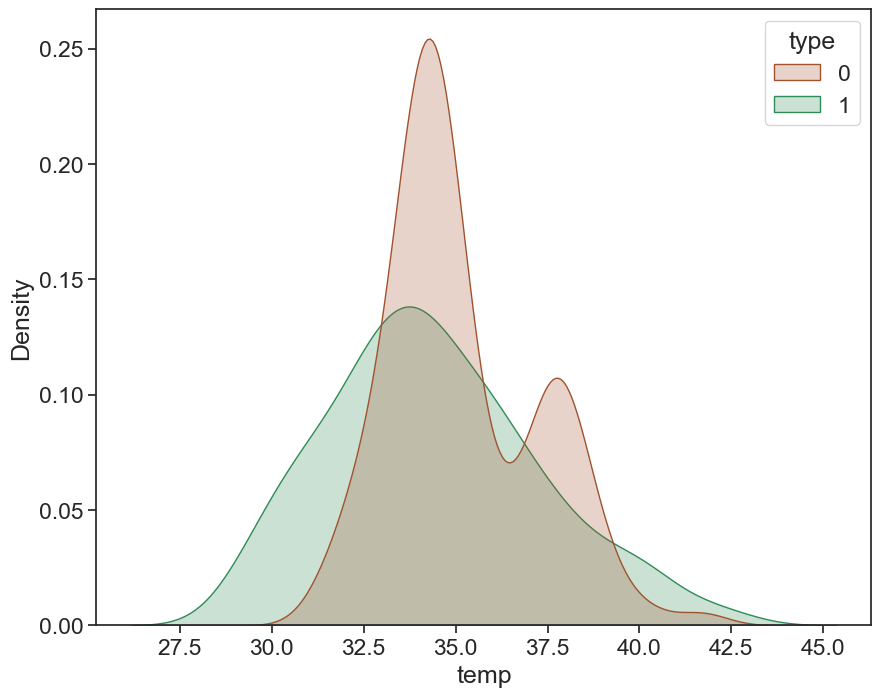

In [177]:
sns.kdeplot(
    matched,
    x="temp",
    hue="type",
    common_norm=False,
    fill=True,
    palette=[BROWN, GREEN],
)

In [178]:
temp = matched.dropna(subset=["temp"])
temp_control = temp.loc[temp["type"] == 0, "temp"].to_numpy()
temp_treatment = temp.loc[temp["type"] == 1, "temp"].to_numpy()

ks_2samp(
    temp_control,
    temp_treatment,
)

KstestResult(statistic=np.float64(0.2576419213973799), pvalue=np.float64(4.3573264988670916e-07), statistic_location=np.float64(33.126772280000026), statistic_sign=np.int8(-1))

In [179]:
ttest_ind(temp_control, temp_treatment)

TtestResult(statistic=np.float64(3.341578348256305), pvalue=np.float64(0.0009015552630029342), df=np.float64(456.0))

# Save

In [180]:
matched.reset_index(drop=True).to_file(results_path / "matched_points.gpkg")

In [181]:
geemap.download_ee_image(
    lst,
    results_path / "temperature.tif",
    bounds_ee,
    crs="EPSG:32623",
    scale=30,
)
geemap.download_ee_image(
    canopy_mask,
    results_path / "green_zones.tif",
    bounds_ee,
    crs="EPSG:32623",
    scale=30,
)

  0%|          |0/2 tiles [00:00<?]

  0%|          |0/1 tiles [00:00<?]